In [ ]:
import os
import numpy as np
import pandas as pd
# file_path = ('/kaggle/input/datasets/andrewmvd/fetal-health-classification/fetal_health.csv')
# Đường dẫn cũ: '/kaggle/input/datasets/andrewmvd/fetal-health-classification/fetal_health.csv'
# Cập nhật đường dẫn tệp dữ liệu để khớp với cấu trúc thư mục dự án MachineLearning/data/
file_path = 'fetal_health.csv' # Dùng '../fetal_health.csv' tùy thuộc vào vị trí của tệp so với thư mục làm việc hiện tại
df = pd.read_csv(file_path)

# Tiền xử lý dữ liệu

In [2]:
df.shape # Số hàng ,số cột

(2126, 22)

In [3]:
df.head() # Hiển thị 5 dòng đầu của dữ liệu

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [4]:
df.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

Thông tin 22 thuộc tính của dữ liệu:
* Các chỉ số về Nhịp tim và Cử động thai (Tính trên mỗi giây):
  
1. ***baseline value***: Nhịp tim cơ bản của thai nhi (FHR - Fetal Heart Rate).
2. ***accelerations***: Số lần tăng nhịp tim thai (Số gia tốc mỗi giây).
3. ***fetal_movement***: Số cử động của thai nhi mỗi giây.
4. ***uterine_contractions***: Số lần co thắt tử cung mỗi giây.
5. ***light_decelerations***: Số lần giảm nhịp tim thai nhẹ (LD).
6. ***severe_decelerations***: Số lần giảm nhịp tim thai nghiêm trọng (SD).
7. ***prolongued_decelerations***: Số lần giảm nhịp tim thai kéo dài (PD).
   
* Các chỉ số về sự Dao động nhịp tim (Variability):
  
8. ***abnormal_short_term_variability***: Tỷ lệ % thời gian nhịp tim thai có mức dao động ngắn hạn (STV) bất thường.
9. ***mean_value_of_short_term_variability***: Giá trị trung bình của dao động nhịp tim ngắn hạn.
10. ***percentage_of_time_with_abnormal_long_term_variability***: Tỷ lệ % thời gian nhịp tim thai có mức dao động dài hạn (LTV) bất thường.
11. ***mean_value_of_long_term_variability***: Giá trị trung bình của dao động nhịp tim dài hạn.
* Các chỉ số trích xuất từ Biểu đồ tần suất (Histogram) của nhịp tim:
  
12. ***histogram_width***: Độ rộng của biểu đồ (Khoảng chênh lệch giữa nhịp tim cao nhất và thấp nhất).
13. ***histogram_min***: Mức nhịp tim thấp nhất ghi nhận được trên biểu đồ.
14. ***histogram_max***: Mức nhịp tim cao nhất ghi nhận được trên biểu đồ.
15. ***histogram_number_of_peaks***: Số lượng đỉnh trên biểu đồ (thể hiện các nhịp tim lặp lại nhiều lần).
16. ***histogram_number_of_zeroes***: Số lượng điểm có giá trị bằng 0 trên biểu đồ.
17. ***histogram_mode***: Giá trị nhịp tim xuất hiện nhiều nhất (Mode) trên biểu đồ.
18. ***histogram_mean***: Giá trị nhịp tim trung bình (Mean) trên biểu đồ.
19. ***histogram_median***: Giá trị nhịp tim trung vị (Median) trên biểu đồ.
20. ***histogram_variance***: Phương sai (độ phân tán nhịp tim) của biểu đồ.
21. ***histogram_tendency***: Xu hướng của biểu đồ (Thường quy định: -1 = lệch trái/giảm, 0 = đối xứng/bình thường, 1 = lệch phải/tăng).
22. ***fetal_health***: Tình trạng sức khỏe thai nhi: 1: Bình thường - 2: Nghi ngờ, cần theo dõi thêm - 3: Bệnh lý,bất thường cảnh báo nguy hiểm.


In [5]:
df.info() #Lệnh df.info() giúp biết nhanh dataset có bao nhiêu dòng, bao nhiêu cột, kiểu dữ liệu của từng cột, và có bị thiếu dữ liệu không.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

Mặc dù toàn bộ dữ liệu hiển thị dưới dạng số, nhưng thực chất nó có chứa các biến phân loại đã được mã hóa sẵn (Label Encoding). Cụ thể, biến **histogram_tendency** dùng các số **-1**, **0**, **1** để đại diện cho hình dáng biểu đồ (**lệch trái**, **đối xứng**, **lệch phải**), và biến mục tiêu **fetal_health** dùng nhãn **1**, **2**,**3**để chỉ tình trạng thai nhi (**bình thường**, **nghi ngờ**, **bệnh lý**). Nên có thể bỏ qua bước chuyển đổi dữ liệu

In [6]:
df.isnull().sum() # Kiểm tra số lượng giá trị bị thiếu (missing values) trong từng cột của dataset.

,0
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


In [7]:
df.nunique() # Dùng để đếm số lượng giá trị duy nhất (unique) trong mỗi cột của dataset.

,0
baseline value,48
accelerations,20
fetal_movement,102
uterine_contractions,16
light_decelerations,16
severe_decelerations,2
prolongued_decelerations,6
abnormal_short_term_variability,75
mean_value_of_short_term_variability,57
percentage_of_time_with_abnormal_long_term_variability,87


In [8]:
df.duplicated().sum() # Kiểm tra trong dataset có bao nhiêu dòng trung lặp.

np.int64(13)

Trong bộ dữ liệu Fetal Health, sự trùng lặp có thể xảy ra do:

Lỗi kỹ thuật: Máy đo ghi đè dữ liệu hoặc lưu hai lần cùng một kết quả của một bệnh nhân.

Lỗi nhập liệu: Người nhập dữ liệu gõ hai lần cùng một dòng.

Trùng hợp ngẫu nhiên (Rất hiếm): Hai bệnh nhân (hoặc cùng một bệnh nhân đo 2 lần khác nhau) có tất cả 22 chỉ số tim thai và cơn gò giống hệt nhau đến từng số thập phân. Tuy nhiên, với dữ liệu sinh học có độ chính xác cao như nhịp tim, xác suất này gần như bằng 0.

In [9]:
df = df.drop_duplicates() # Loại bỏ dòng trùng lặp

In [10]:
df.duplicated().sum()

np.int64(0)

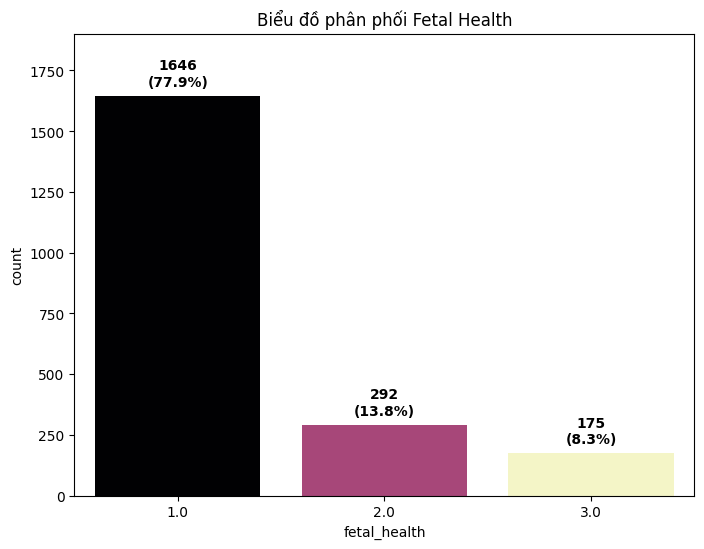

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
# Font tiếng việt
plt.rcParams['font.family'] = 'DejaVu Sans'

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='fetal_health', data=df, palette='magma', hue='fetal_health', legend=False)

total = len(df)
for p in ax.patches:
    h = p.get_height()
    percent = f'{100*h/total:.1f}%'
    ax.annotate(f'{int(h)}\n({percent})', (p.get_x() + p.get_width()/2., h),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.title("Biểu đồ phân phối Fetal Health")
plt.ylim(0, total * 0.9)
# os.makedirs("result/figures", exist_ok=True)
# plt.savefig('result/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Biểu đồ đếm các nhãn mục tiêu cho thấy dữ liệu bị mất cân bằng

**Biểu đồ nhiệt**

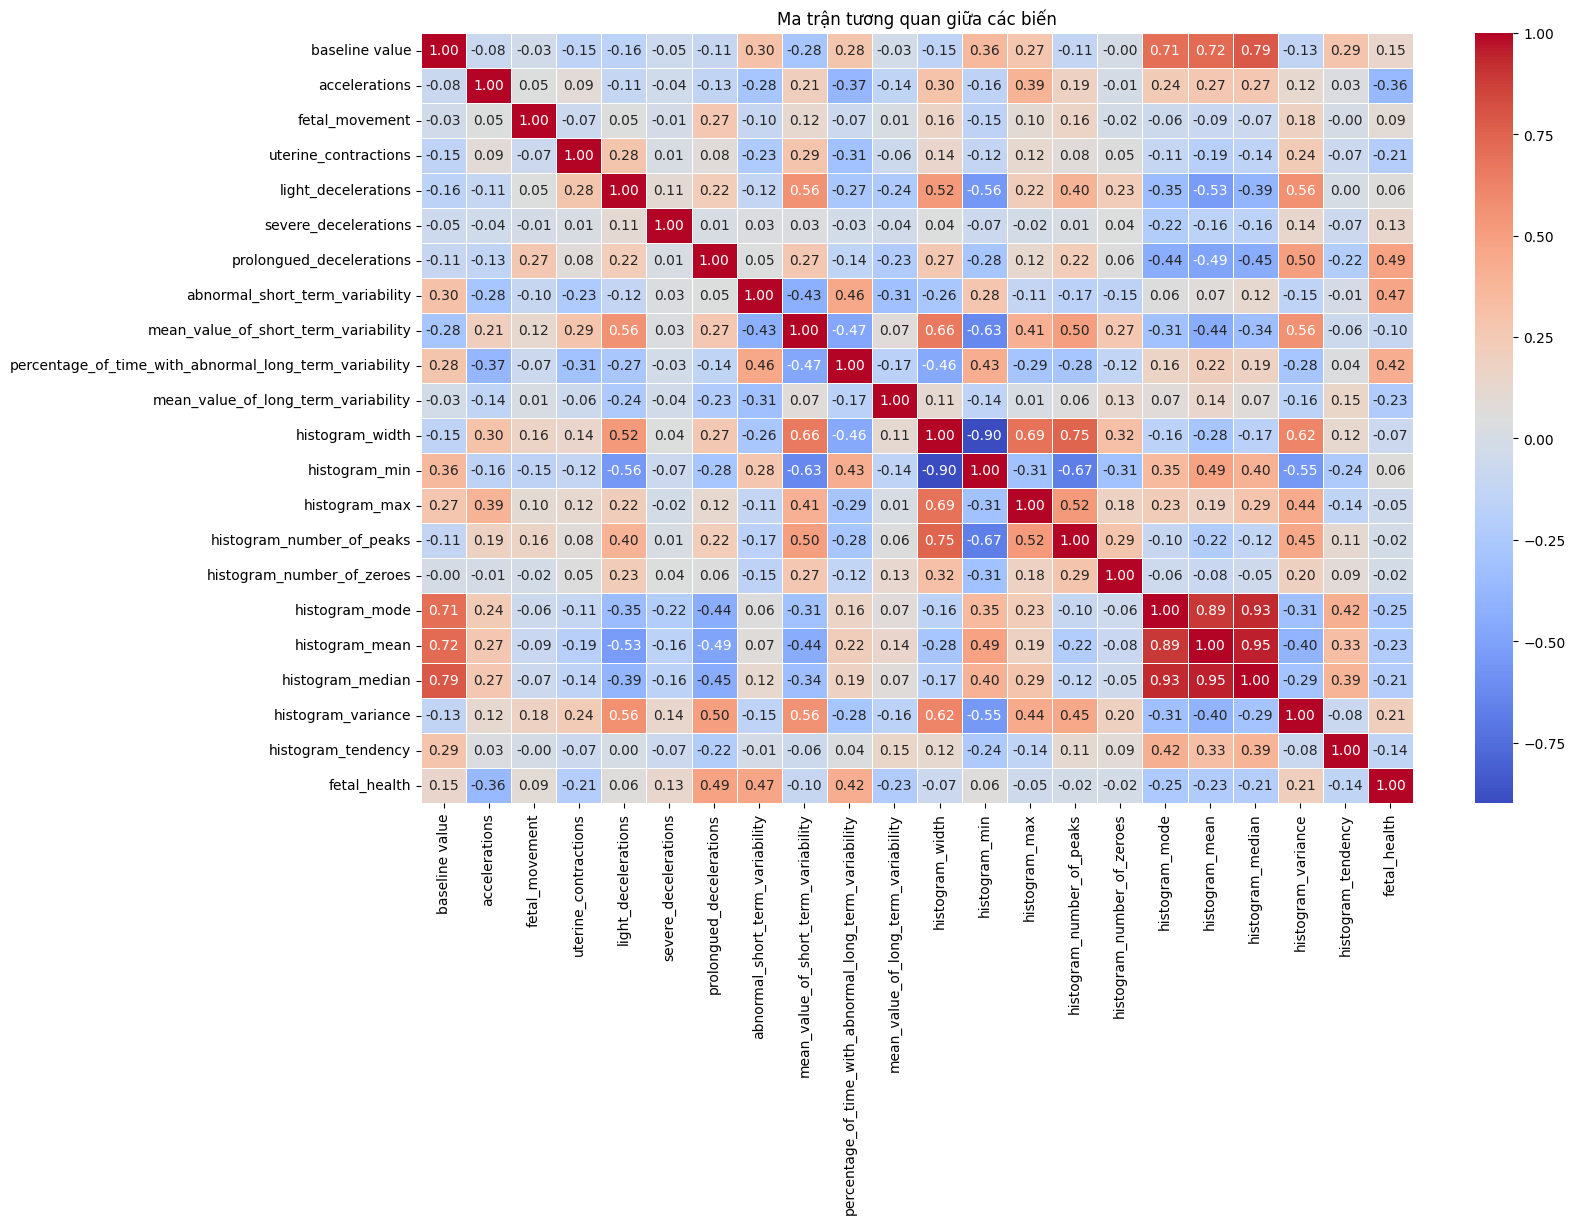

In [12]:
plt.figure(figsize=(16, 10))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến")
# plt.savefig('result/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Dựa trên ma trận tương quan, có thể thấy rằng các đặc trưng "**accelerations**", "**prolongued_decelerations**", "**abnormal_short_term_variability**", "**percentage_of_time_with_abnormal_long_term_variability**" và "**mean_value_of_long_term_variability**" có mức độ tương quan cao với **fetal_health**.

## Thống kê sơ bộ về dữ liệu

Lệnh **df.describe()** trả về :


*   **count**: số lượng phần tử không bị thiếu (non-null).
*   **mean**: giá trị trung bình.

*   **std**: độ lệch chuẩn.
*   **min**: giá trị nhỏ nhất.
*   **25%**: phân vị mức 25 (Q1).
*   **50%**: phân vị mức 50 (median).
*   **75%**: phân vị mức 75 (Q3).
*   **max**: giá trị lớn nhất.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2113.0,133.304780,9.837451,106.0,126.000,133.000,140.000,160.000
accelerations,2113.0,0.003188,0.003871,0.0,0.000,0.002,0.006,0.019
fetal_movement,2113.0,0.009517,0.046804,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2113.0,0.004387,0.002941,0.0,0.002,0.005,0.007,0.015
light_decelerations,2113.0,0.001901,0.002966,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2113.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2113.0,0.000159,0.000592,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2113.0,46.993848,17.177782,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2113.0,1.335021,0.884368,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2113.0,9.795078,18.337073,0.0,0.000,0.000,11.000,91.000


**1**. Dữ liệu sạch, không có giá trị khuyết thiếu:

   Tất cả 22 biến đều có thuộc tính count đồng loạt bằng 2113. Điều này cho thấy bộ dữ liệu có tính    toàn vẹn cao, không tồn tại bất kỳ ô trống (Null/NA) nào.

**2**. Dấu hiệu mất cân bằng dữ liệu nghiêm trọng

   Tại biến mục tiêu fetal_health, giá trị chạy từ 1 (min) đến 3 (max). Tuy nhiên, cả 3 mốc phân vị    25%, 50% (trung vị) và 75% đều mang giá trị là 1. Mức trung bình (mean) cũng chỉ ở khoảng 1.30.     Điều này khẳng định hơn 75% dữ liệu nghiêng về nhãn 1 (Thai nhi bình thường), trong khi các ca      bệnh lý (nhãn 2, 3) chiếm tỷ lệ rất nhỏ.

**3**. Sự chênh lệch lớn về thang đo:

   Quan sát giá trị lớn nhất (max), sự chênh lệch hàng ngàn lần giữa các biến
   Các biến về tần suất đo đạc có biên độ cực nhỏ (Ví dụ: severe_decelerations có max chỉ là 0.001).
   Các biến trích xuất từ biểu đồ lại có biên độ rất lớn (Ví dụ: histogram_max có max là 238,          histogram_variance lên tới 269).

**4**. Xuất hiện các điểm ngoại lệ (Outliers) có thể là dấu hiệu bệnh lý:

   Sự chênh lệch bất thường giữa phân vị 75% (Q3) và giá trị lớn nhất (max) tại một số biến cho        thấy sự tồn tại của các điểm ngoại lệ.
   histogram_variance: 75% dữ liệu có phương sai nhỏ hơn 24, nhưng giá trị lớn nhất vọt lên 269        (gấp hơn 10 lần).
   percentage_of_time_with_abnormal_long_term_variability: Ở mức 75% chỉ là 11.0, nhưng giá trị max    lên đến 91.0.
   Các giá trị ngoại lai cực đoan này rất có thể không phải do lỗi nhiễu, mà chính là đặc trưng        nhận diện của các ca thai nhi có bệnh lý nặng (nhãn 3). Cần giữ lại và trực quan hóa thêm bằng      biểu đồ Boxplot để kiểm chứng.

 **Biểu đồ boxplot**

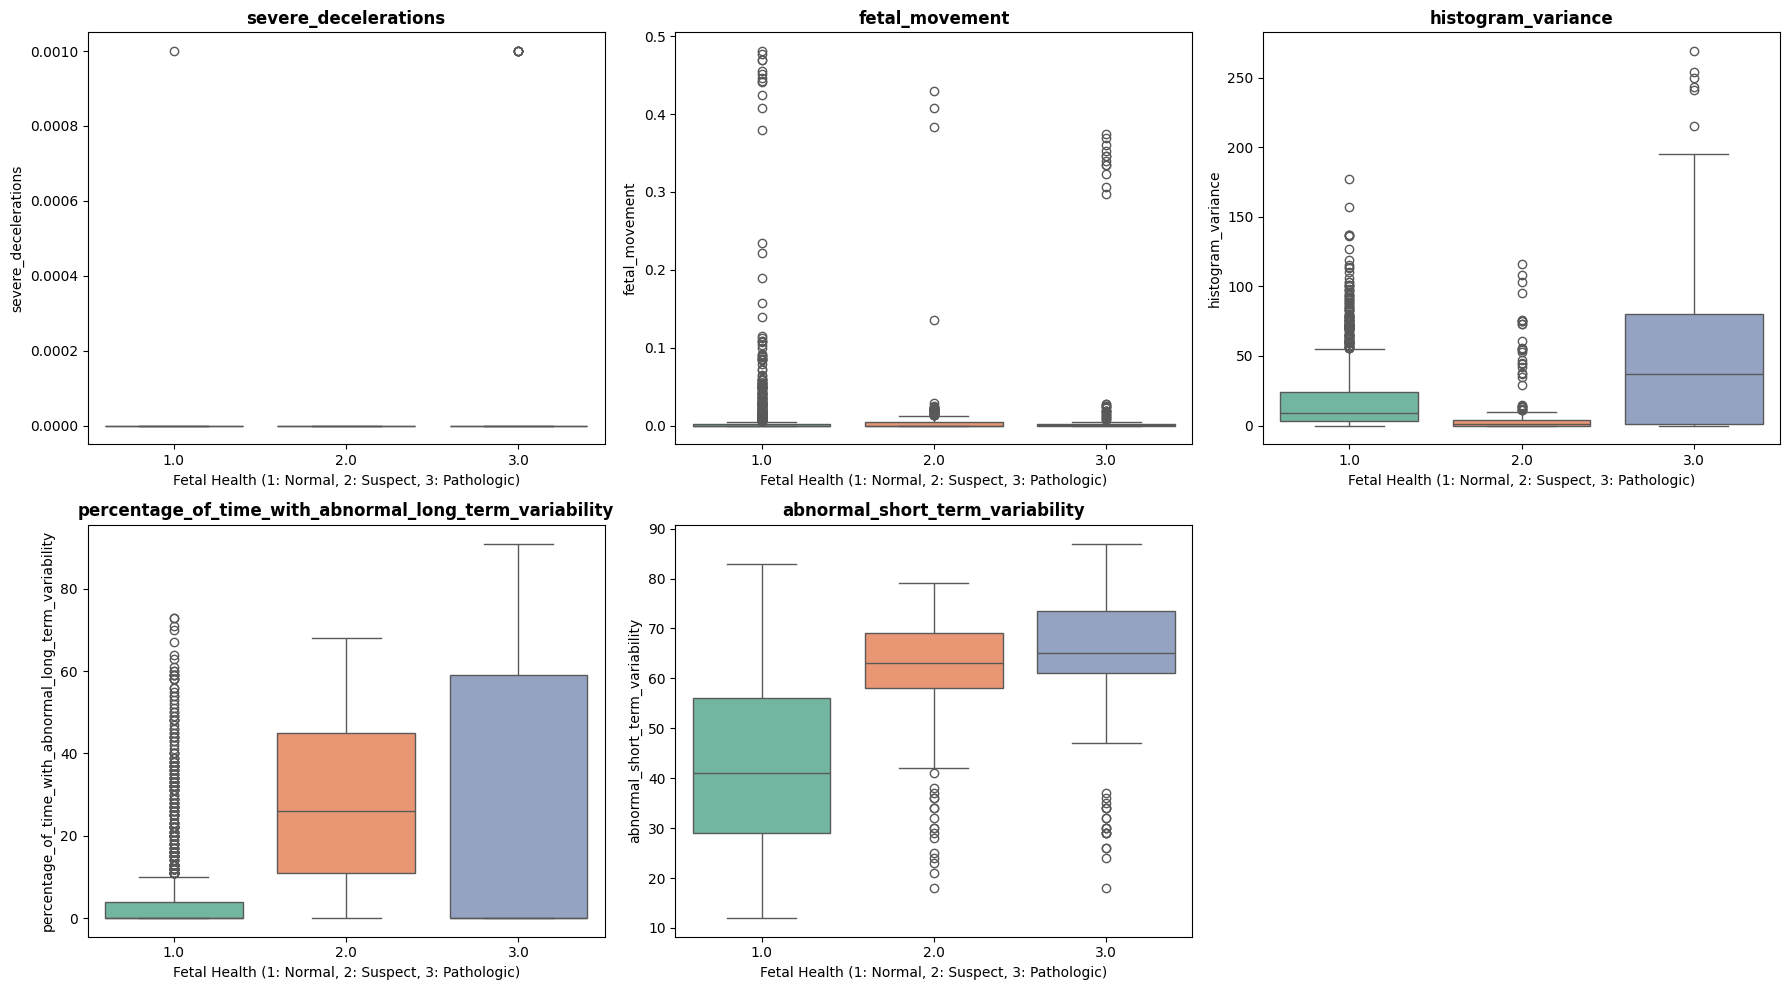

In [14]:
outlier_features = [
    'severe_decelerations',                                    # Số lần giảm nhịp tim thai nghiêm trọng
    'fetal_movement',                                          # Số cử động của thai nhi mỗi giây
    'histogram_variance',                                      # Phương sai nhịp tim dao động mạnh
    'percentage_of_time_with_abnormal_long_term_variability',  # Tỷ lệ % thời gian nhịp tim thai có mức dao động dài hạn (LTV) bất thường
    'abnormal_short_term_variability'                          # Tỷ lệ % thời gian nhịp tim thai có mức dao động ngắn hạn (STV) bất thường
]

plt.figure(figsize=(18, 10))
for i, feature in enumerate(outlier_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='fetal_health', y=feature, data=df, hue='fetal_health', palette='Set2', legend=False)
    plt.title(f'{feature}', fontsize=12, fontweight='bold')
    plt.xlabel('Fetal Health (1: Normal, 2: Suspect, 3: Pathologic)')

plt.tight_layout()
# plt.savefig('result/figures/boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Biểu đồ hộp rất hữu ích để chỉ ra liệu có các quan sát bất thường(ngoại lệ) trong tập dữ liệu hay không. Ở trên áp dụng biểu đồ hộp để khám phá các ngoại lệ từ mỗi dữ liệu và sơ đồ cho từng thuộc tính được trình bày ở trên. Các biểu đồ hộp tiết lộ các ngoại lệ trong một số thuộc tính. Tuy nhiên, xem xét rằng bộ dữ liệu đã được các chuyên gia phòng khám xem xét và giải thích, các ngoại lệ rõ ràng được xác định trong các biểu đồ hộp có thể không bất thường trong môi trường lâm sàng. Thay vào đó, chúng có thể biểu thị các biến thể có liên quan đến lâm sàng, chẳng hạn như các chỉ số về suy thai hoặc tình trạng sức khỏe của bà mẹ. Sẽ không có hành động nào được thực hiện đối với các giá trị nằm ngoài phạm vi biểu đồ hộp.

## Chuẩn hóa dữ liệu

In [15]:
# Tách đâu vào và đầu ra
X = df.drop(['fetal_health'], axis=1)
y = df['fetal_health']

In [16]:
#Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_copy = X.copy()
X_scaled = scaler.fit_transform(X_copy)
X_scaled = pd.DataFrame(X_scaled, columns=X_copy.columns)

In [17]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2113.0,-1.143325e-15,1.000237,-2.776252,-0.742724,-0.030989,0.680746,2.714274
accelerations,2113.0,6.725440e-18,1.000237,-0.823776,-0.823776,-0.307036,0.726444,4.085254
fetal_movement,2113.0,-1.345088e-17,1.000237,-0.203392,-0.203392,-0.203392,-0.139280,10.075993
uterine_contractions,2113.0,8.070528e-17,1.000237,-1.492245,-0.811961,0.208464,0.888747,3.609880
light_decelerations,2113.0,-8.070528e-17,1.000237,-0.641203,-0.641203,-0.641203,0.370643,4.418027
severe_decelerations,2113.0,-6.725440e-18,1.000237,-0.057653,-0.057653,-0.057653,-0.057653,17.345234
prolongued_decelerations,2113.0,4.035264e-17,1.000237,-0.269640,-0.269640,-0.269640,-0.269640,8.183605
abnormal_short_term_variability,2113.0,-1.345088e-17,1.000237,-2.037640,-0.873069,0.116815,0.815557,2.329499
mean_value_of_short_term_variability,2113.0,-4.035264e-17,1.000237,-1.283731,-0.718221,-0.152712,0.412798,6.407199
percentage_of_time_with_abnormal_long_term_variability,2113.0,2.690176e-17,1.000237,-0.534294,-0.534294,-0.534294,0.065725,4.429504


# Phân tích và trực quan hóa dữ liệu

## PCA

In [18]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Tỷ lệ phương sai tích lũy
explained_var = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_var)
print("Tổng phương sai giữ lại:", explained_var.sum())

Explained variance ratio: [0.28860247 0.16723956 0.08659547 0.07092018 0.05800729 0.04867498
 0.04672001 0.04417223 0.03634733 0.03052871 0.0274108  0.02379009
 0.01853914 0.01561618 0.01261268 0.00861987 0.00635015 0.00560868
 0.00236416 0.00128002 0.        ]
Tổng phương sai giữ lại: 1.0


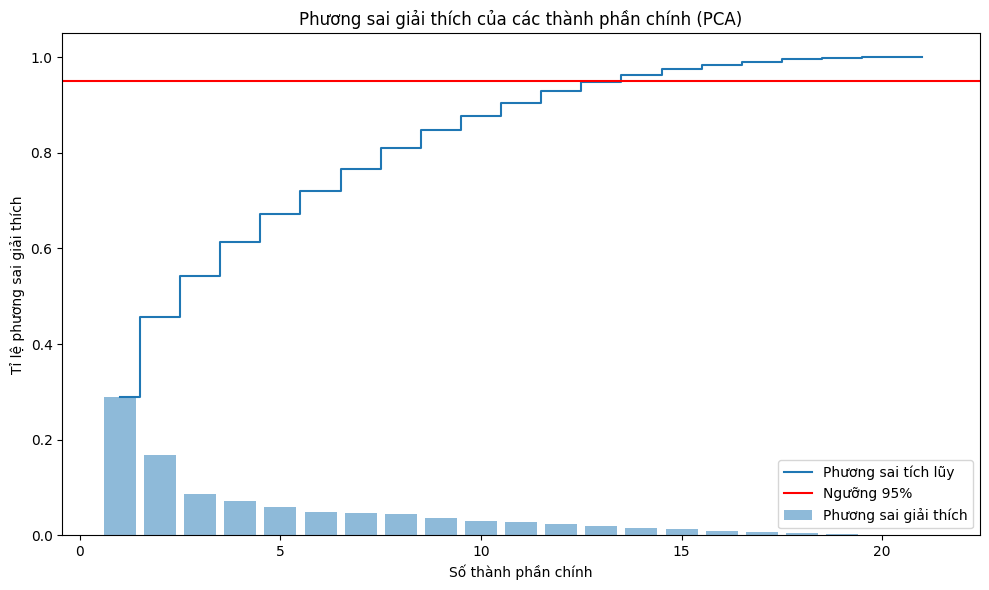

In [19]:
import matplotlib.pyplot as plt

# Tính phương sai tích lũy
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.5, align='center',
        label='Phương sai giải thích')
plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid',
         label='Phương sai tích lũy')
plt.axhline(y=0.95, color='r', linestyle='-', label='Ngưỡng 95%')
plt.xlabel('Số thành phần chính')
plt.ylabel('Tỉ lệ phương sai giải thích')
plt.title('Phương sai giải thích của các thành phần chính (PCA)')
plt.legend(loc='best')
plt.tight_layout()
# plt.savefig('result/figures/pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Số thành phần chính cần để giữ 95% phương sai: {n_components_95}")

Số thành phần chính cần để giữ 95% phương sai: 14


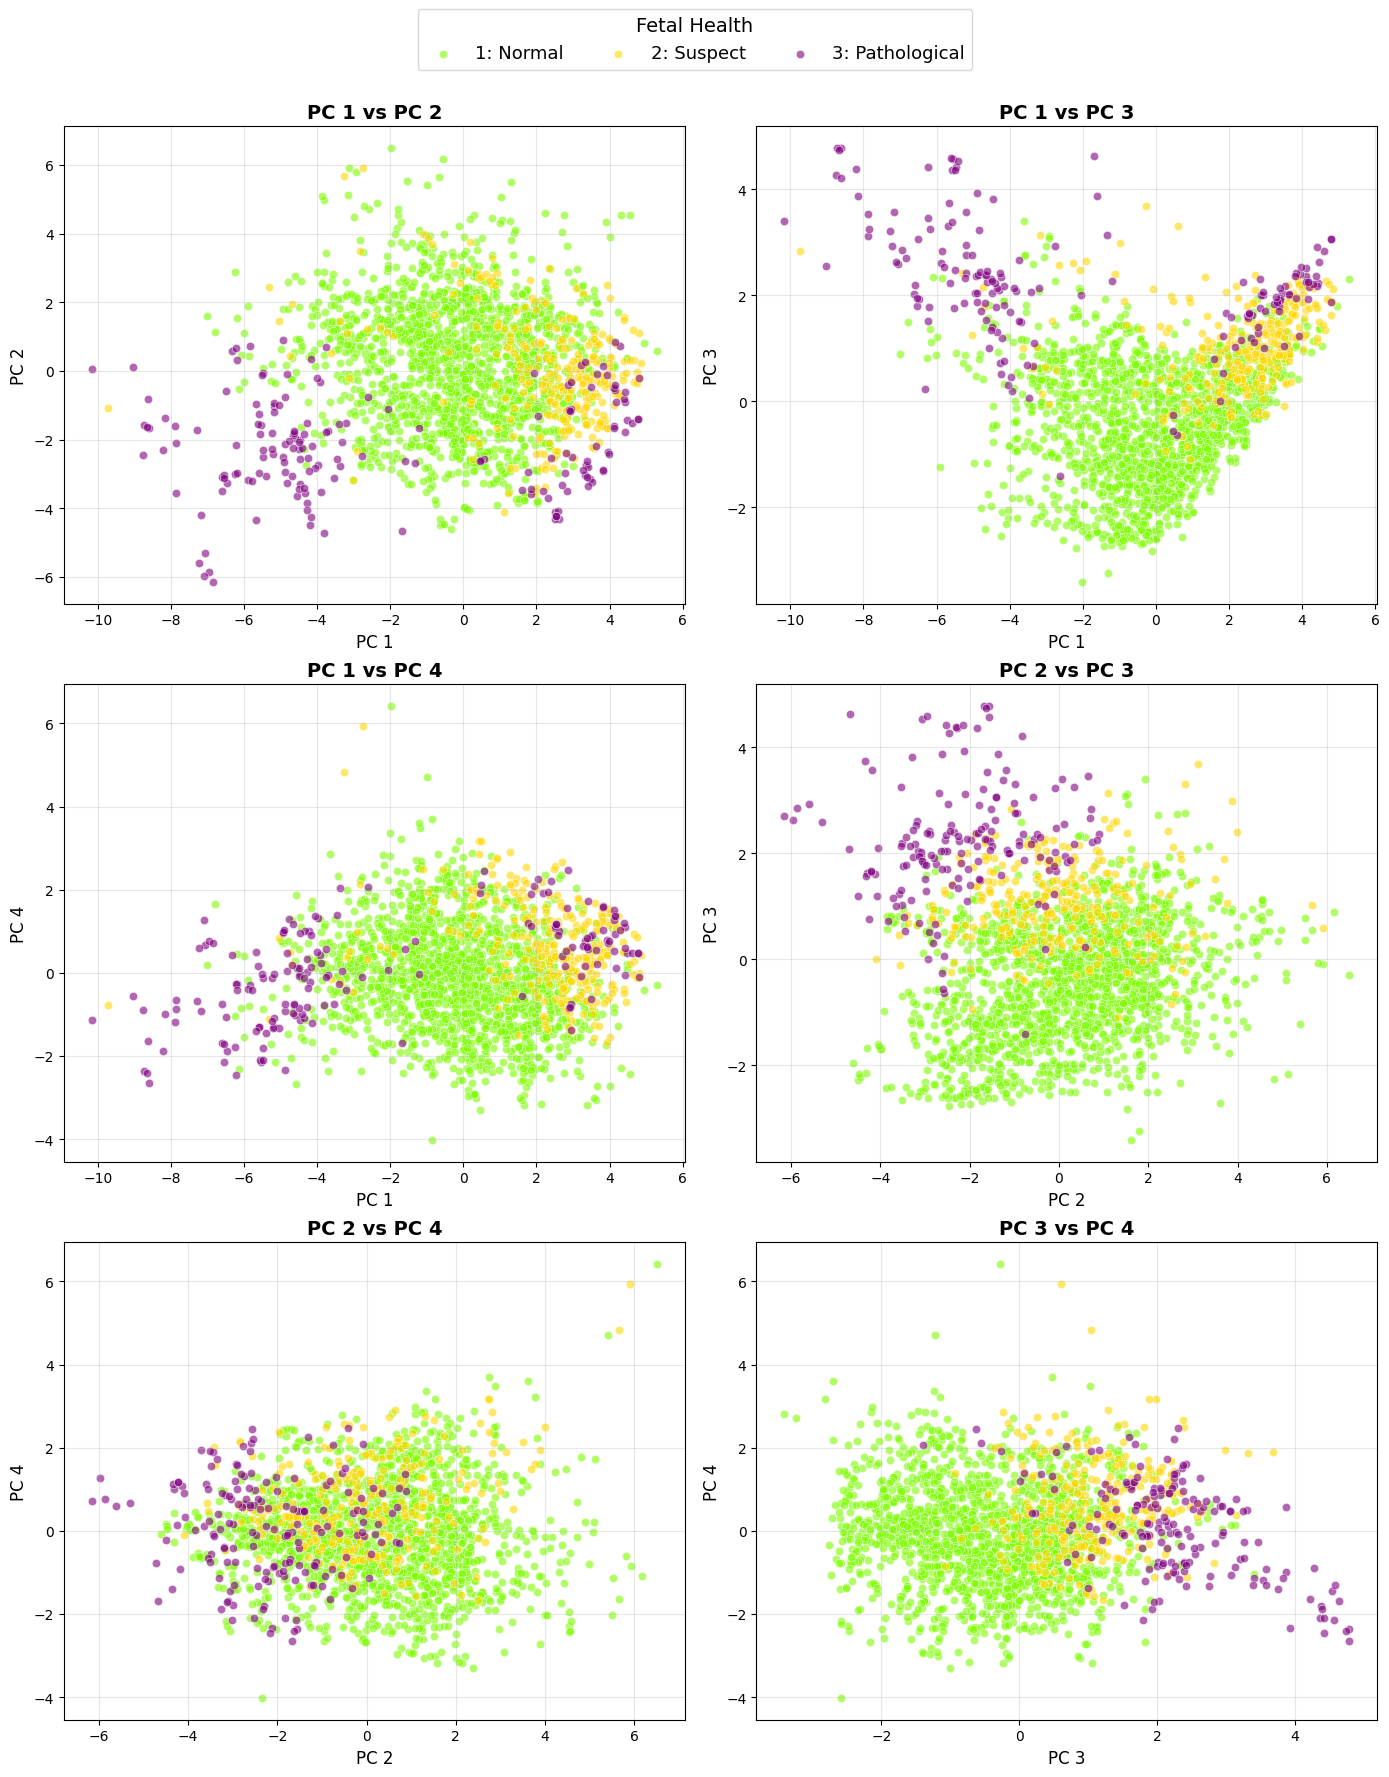

In [21]:
# Trực quan hóa cặp 6 thành phần chính đầu tiên

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

# Xanh lá 1, Cam 2, Đỏ 3
colors = {1: '#7CFC00', 2: '#FFD700', 3: '#800080'}
labels_dict = {1: '1: Normal', 2: '2: Suspect', 3: '3: Pathological'}

for (pc1, pc2), ax in zip(pairs, axes.flatten()):
    for health_status in [1, 2, 3]:
        idx = (y == health_status)
        ax.scatter(X_pca[idx, pc1], X_pca[idx, pc2],
                   c=colors[health_status],
                   label=labels_dict[health_status],
                   alpha=0.6,
                   edgecolors='w', linewidth=0.5)
    ax.set_xlabel(f'PC {pc1+1}', fontsize=12)
    ax.set_ylabel(f'PC {pc2+1}', fontsize=12)
    ax.set_title(f'PC {pc1+1} vs PC {pc2+1}', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99),
           ncol=3, fontsize=13, title="Fetal Health", title_fontsize=14)

plt.tight_layout()
fig.subplots_adjust(top=0.92)
# plt.savefig('result/figures/pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()

## LDA

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print(f"Tỷ lệ phương sai giải thích phân lớp của LDA 1: {lda.explained_variance_ratio_[0]*100:.2f}%")
print(f"Tỷ lệ phương sai giải thích phân lớp của LDA 2: {lda.explained_variance_ratio_[1]*100:.2f}%")

Tỷ lệ phương sai giải thích phân lớp của LDA 1: 80.31%
Tỷ lệ phương sai giải thích phân lớp của LDA 2: 19.69%


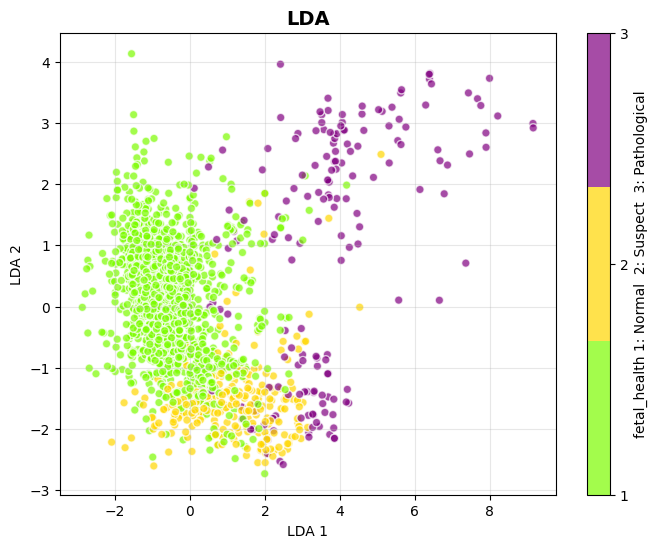

In [23]:
from matplotlib.colors import ListedColormap

cmap_3_colors = ListedColormap(['#7CFC00', '#FFD700', '#800080'])
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap=cmap_3_colors, alpha=0.7,edgecolors='w')

cbar = plt.colorbar(scatter, ticks=[1, 2, 3])
cbar.set_label('fetal_health 1: Normal  2: Suspect  3: Pathological')

plt.xlabel('LDA 1')
plt.ylabel('LDA 2')
plt.title('LDA', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
# plt.savefig('result/figures/lda_2d.png', dpi=300, bbox_inches='tight')
plt.show()

Thuật toán LDA đã thực hiện tương đối tốt việc kéo dãn nhóm Bệnh lý (màu đỏ) tách dần về phía bên phải của trục tọa độ (vùng LDA 1 > 2). Có một sự phân tách khá rõ ràng giữa nhóm Bệnh lý và nhóm Bình thường.
Quan sát trên đồ thị, các điểm màu cam bị kẹp giữa và đan xen với phần rìa dưới của nhóm Bình thường. Điều này phản ánh đúng thực tế y khoa: ranh giới sinh lý học giữa một thai nhi 'bình thường' và 'bắt đầu có dấu hiệu nghi ngờ' là rất mong manh

# Phân cụm K-mean

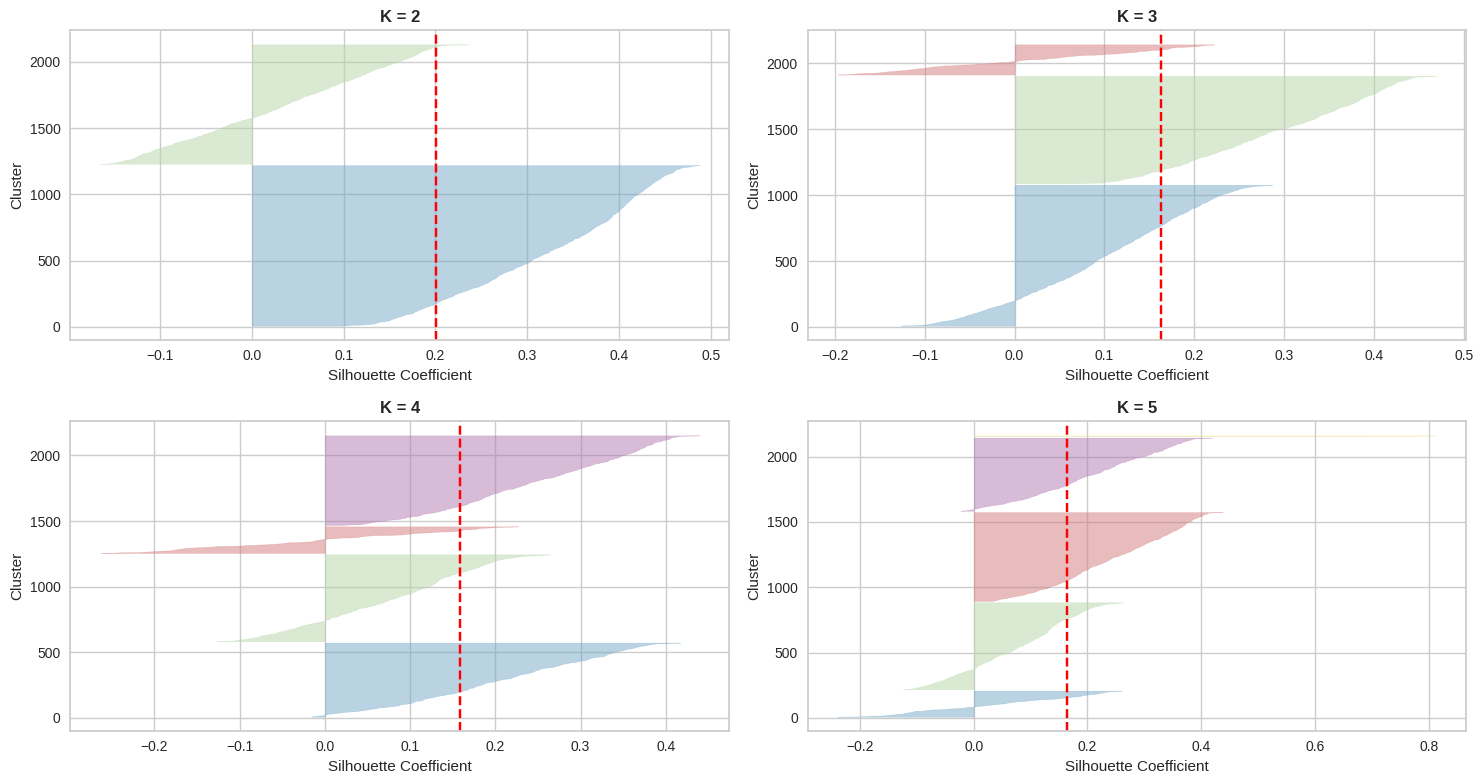

In [24]:
import math
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

def silhouette_visualizer(K_max, data):
    num_plots = K_max - 1
    rows = math.ceil(num_plots / 2)
    fig, ax = plt.subplots(rows, 2, figsize=(15, 4 * rows))
    ax = ax.flatten()
    custom_colors = ['#76a8c8', '#b5d5a7', '#d37a7b', '#b079b0', '#ece08c']

    for i, k in enumerate(range(2, K_max + 1)):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

        visualizer = SilhouetteVisualizer(kmeans, colors=custom_colors, ax=ax[i])
        visualizer.fit(data)

        ax[i].set_title(f'K = {k}', fontweight='bold')
        ax[i].set_xlabel("Silhouette Coefficient")
        ax[i].set_ylabel("Cluster")

    for j in range(num_plots, len(ax)):
        fig.delaxes(ax[j])

    plt.tight_layout()
    # plt.savefig('result/figures/silhouette.png', dpi=300, bbox_inches='tight')
    plt.show()

silhouette_visualizer(5, X_pca)

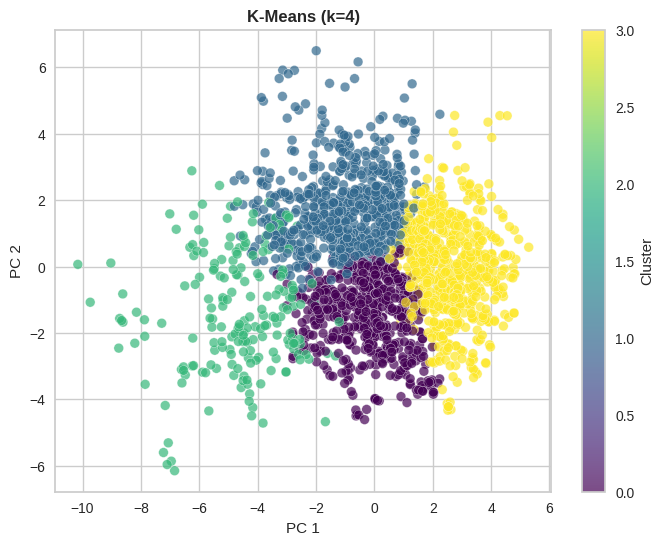

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7, edgecolors='w')

plt.title('K-Means (k=4)', fontweight='bold')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.colorbar(label='Cluster')
# plt.savefig('result/figures/kmeans_pca.png', dpi=300, bbox_inches='tight')
plt.show()

Khi áp dụng thuật toán gom cụm K-Means (k=4) trên không gian 2 chiều PC1 và PC2, thuật toán đã phân chia không gian thành 4 cụm dựa trên khoảng cách hình học đơn thuần. Tuy nhiên, khi đối chiếu với phân phối nhãn thực tế đã phân tích ở phần trước, ta nhận thấy các ranh giới hình học này hoàn toàn không vạch ra được ranh giới y khoa. Một cụm K-Means có thể chứa lẫn lộn cả 3 trạng thái.

In [26]:
from sklearn import metrics

print("CROSSTAB\n", pd.crosstab(y, clusters, rownames=['y_true'], colnames=['y_kmeans']))

cm = metrics.cluster.contingency_matrix(y, clusters)
purity = np.sum(np.amax(cm, axis=0)) / np.sum(cm)

# Tính ARI, NMI
ari = metrics.adjusted_rand_score(y, clusters)
nmi = metrics.normalized_mutual_info_score(y, clusters)

print("\nĐỘ ĐO ĐỊNH LƯỢNG ")
print(f"Purity: {purity:.4f} | ARI: {ari:.4f} | NMI: {nmi:.4f}")

CROSSTAB
 y_kmeans    0    1    2    3
y_true                      
1.0       539  631   82  394
2.0        17   31   12  232
3.0         9    0  109   57

ĐỘ ĐO ĐỊNH LƯỢNG 
Purity: 0.7918 | ARI: 0.0964 | NMI: 0.1877


Phân tích bảng chéo cho thấy không có cụm K-Means nào hoàn toàn tinh khiết. Mặc dù thuật toán đã phần nào tạo ra được một cụm thiên về Bệnh lý (Cụm 2) và một cụm chứa nhiều ca Nghi ngờ (Cụm 3), nhưng số lượng các ca Bình thường (nhãn 1) quá áp đảo đã tràn sang và gây nhiễu mọi cụm. Điều này chứng tỏ ranh giới hình học không trùng khớp với ranh giới y khoa.

Chỉ số Purity đạt 0.7918, tuy nhiên con số này là hệ quả của hiện tượng mất cân bằng dữ liệu (Class Imbalance) khi nhãn Bình thường chiếm tỷ trọng quá lớn, chứ không phản ánh sức mạnh gom cụm của K-Means.

Chỉ số ARI chỉ đạt mức rất thấp (0.0964). Thước đo nghiêm ngặt này khẳng định rằng: Cấu trúc phân cụm do K-Means tìm ra dựa trên khoảng cách Euclidean gần như không có sự tương đồng nào với cấu trúc 3 trạng thái sức khỏe thực tế do bác sĩ dán nhãn.

Chỉ số NMI đạt 0.1877, cho thấy thông tin về mặt vị trí không gian (cụm) cung cấp rất ít giá trị để suy luận ra nhãn đầu ra thực tế.

# Mô hình phân loại

In [27]:
from sklearn.model_selection import train_test_split
# Chia tỷ lệ
ratios = [(0.8, 0.2), (0.7, 0.3), (0.6, 0.4)]  # 4:1, 7:3, 6:4
splits = {}

for train_size, val_size in ratios:
    # Chia tách dữ liệu
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=val_size, random_state=42, stratify=y
    )

    # Chuẩn hóa dữ liệu
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    splits[f"{int(train_size*10)}:{int(val_size*10)}"] = (X_train_scaled, X_test_scaled, y_train, y_test)

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
"Naive Bayes": GaussianNB(),

"SoftMax Regression": LogisticRegression(solver='lbfgs', max_iter=1000),

"SVM": SVC(kernel='rbf', probability=True)
}


In [29]:
import time
all_results_goc, detailed_reports_goc, times_goc = {}, {}, {}
for ratio, (X_train_s, X_test_s, y_train, y_test) in splits.items():
    all_results_goc[ratio] = {}
    detailed_reports_goc[ratio] = {}
    times_goc[ratio] = {}
    for name, model in models.items():
        # Train
        start = time.time()
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
        end = time.time()

        all_results_goc[ratio][name] = accuracy_score(y_test, y_pred)
        # Precision, Recall, F1-score
        detailed_reports_goc[ratio][name] = classification_report(y_test, y_pred, zero_division=0)
        times_goc[ratio][name] = end - start
print("\nDone")


Done


In [30]:
print("       DỮ LIỆU GỐC       ")

for ratio in detailed_reports_goc.keys():
    print(f"\n\nTỈ LỆ CHIA (TRAIN:TEST) = {ratio}")

    for name, report in detailed_reports_goc[ratio].items():
        acc = all_results_goc[ratio][name]
        elapsed = times_goc[ratio][name]

        print(f"\n M: [{name}]")
        print(f"   Độ chính xác (Accuracy): {acc:.2%}")
        print("   Báo cáo chi tiết:")
        print(report)
        print(f"Time: {elapsed:.4f} giây")

       DỮ LIỆU GỐC       


TỈ LỆ CHIA (TRAIN:TEST) = 8:2

 M: [Naive Bayes]
   Độ chính xác (Accuracy): 70.92%
   Báo cáo chi tiết:
              precision    recall  f1-score   support

         1.0       1.00      0.68      0.81       330
         2.0       0.33      0.93      0.49        58
         3.0       0.59      0.57      0.58        35

    accuracy                           0.71       423
   macro avg       0.64      0.73      0.63       423
weighted avg       0.87      0.71      0.75       423

Time: 0.0076 giây

 M: [SoftMax Regression]
   Độ chính xác (Accuracy): 88.89%
   Báo cáo chi tiết:
              precision    recall  f1-score   support

         1.0       0.92      0.96      0.94       330
         2.0       0.64      0.55      0.59        58
         3.0       0.90      0.77      0.83        35

    accuracy                           0.89       423
   macro avg       0.82      0.76      0.79       423
weighted avg       0.88      0.89      0.88       423

Time:

In [31]:
all_results_pca, detailed_reports_pca, times_pca = {}, {}, {}
all_results_lda, detailed_reports_lda, times_lda = {}, {}, {}

# Vòng lặp duyệt qua từng tỷ lệ
for ratio, (X_tr, X_te, y_tr, y_te) in splits.items():
    # Khởi tạo dict con cho tỷ lệ hiện tại
    all_results_pca[ratio], detailed_reports_pca[ratio], times_pca[ratio] = {}, {}, {}
    all_results_lda[ratio], detailed_reports_lda[ratio], times_lda[ratio] = {}, {}, {}

    # Thực hiện PCA & LDA
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_tr)
    X_test_pca = pca.transform(X_te)

    lda = LinearDiscriminantAnalysis(n_components=2)
    X_train_lda = lda.fit_transform(X_tr, y_tr)
    X_test_lda = lda.transform(X_te)

    # Train
    for name, model in models.items():
        # PCA
        start = time.time()
        model.fit(X_train_pca, y_tr)
        y_pred_pca = model.predict(X_test_pca)
        end = time.time()
        all_results_pca[ratio][name] = accuracy_score(y_te, y_pred_pca)
        detailed_reports_pca[ratio][name] = classification_report(y_te, y_pred_pca, zero_division=0)
        times_pca[ratio][name] = end - start

        # LDA
        start = time.time()
        model.fit(X_train_lda, y_tr)
        y_pred_lda = model.predict(X_test_lda)
        end = time.time()
        all_results_lda[ratio][name] = accuracy_score(y_te, y_pred_lda)
        detailed_reports_lda[ratio][name] = classification_report(y_te, y_pred_lda, zero_division=0)
        times_lda[ratio][name] = end - start

print("Done")

Done


In [32]:
print(" DỮ LIỆU GIẢM CHIỀU (PCA & LDA)")

for ratio in detailed_reports_pca.keys():
    print(f"\n\n TỈ LỆ TRAIN:VAL = {ratio} ")

    for name in models.keys():
        print(f"\n Model: {name}")

        print(f"\n[DỮ LIỆU PCA] Accuracy: {all_results_pca[ratio][name]:.2%}")
        print(detailed_reports_pca[ratio][name])
        print(f"Time: {times_pca[ratio][name]:.4f} giây")

        print(f"[DỮ LIỆU LDA] Accuracy: {all_results_lda[ratio][name]:.2%}")
        print(detailed_reports_lda[ratio][name])
        print(f"Time: {times_lda[ratio][name]:.4f} giây")

 DỮ LIỆU GIẢM CHIỀU (PCA & LDA)


 TỈ LỆ TRAIN:VAL = 8:2 

 Model: Naive Bayes

[DỮ LIỆU PCA] Accuracy: 82.98%
              precision    recall  f1-score   support

         1.0       0.93      0.90      0.92       330
         2.0       0.49      0.66      0.56        58
         3.0       0.56      0.43      0.48        35

    accuracy                           0.83       423
   macro avg       0.66      0.66      0.66       423
weighted avg       0.84      0.83      0.83       423

Time: 0.0029 giây
[DỮ LIỆU LDA] Accuracy: 84.16%
              precision    recall  f1-score   support

         1.0       0.92      0.92      0.92       330
         2.0       0.49      0.57      0.52        58
         3.0       0.83      0.54      0.66        35

    accuracy                           0.84       423
   macro avg       0.74      0.68      0.70       423
weighted avg       0.85      0.84      0.84       423

Time: 0.0023 giây

 Model: SoftMax Regression

[DỮ LIỆU PCA] Accuracy: 88.65%


In [33]:
test_sizes = {"4:1": 0.2, "7:3": 0.3, "6:4": 0.4}

print("KIỂM TRA OVERFITTING (SO SÁNH TRAIN ACC VÀ TEST ACC)")

# Tạo một danh sách để gom toàn bộ kết quả vào 1 bảng
overfit_data = []

for ratio, ts in test_sizes.items():
    # Chia tập và chuẩn hóa
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=ts, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)

    # Giảm chiều PCA
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_s)
    X_val_pca = pca.transform(X_val_s)

    # Giảm chiều LDA
    lda = LinearDiscriminantAnalysis(n_components=2)
    X_train_lda = lda.fit_transform(X_train_s, y_train)
    X_val_lda = lda.transform(X_val_s)

    # Chấm điểm Train và Test cho từng loại dữ liệu
    for name, model in models.items():

        # GỐC
        model.fit(X_train_s, y_train)
        acc_train_goc = accuracy_score(y_train, model.predict(X_train_s))
        acc_val_goc = accuracy_score(y_val, model.predict(X_val_s))
        overfit_data.append({
            "Tỉ lệ": ratio, "Data": "Gốc", "Model": name,
            "Train Acc": acc_train_goc, "Test Acc": acc_val_goc,
            "Chênh lệch": acc_train_goc - acc_val_goc
        })

        # PCA
        model.fit(X_train_pca, y_train)
        acc_train_pca = accuracy_score(y_train, model.predict(X_train_pca))
        acc_val_pca = accuracy_score(y_val, model.predict(X_val_pca))
        overfit_data.append({
            "Tỉ lệ": ratio, "Data": "PCA", "Model": name,
            "Train Acc": acc_train_pca, "Test Acc": acc_val_pca,
            "Chênh lệch": acc_train_pca - acc_val_pca
        })

        # LDA
        model.fit(X_train_lda, y_train)
        acc_train_lda = accuracy_score(y_train, model.predict(X_train_lda))
        acc_val_lda = accuracy_score(y_val, model.predict(X_val_lda))
        overfit_data.append({
            "Tỉ lệ": ratio, "Data": "LDA", "Model": name,
            "Train Acc": acc_train_lda, "Test Acc": acc_val_lda,
            "Chênh lệch": acc_train_lda - acc_val_lda
        })

# Bảng kết quả tổng hợp
df_overfit = pd.DataFrame(overfit_data)

# Định dạng các cột số thành phần trăm (%)
df_overfit['Train Acc'] = df_overfit['Train Acc'].map(lambda x: f"{x:.2%}")
df_overfit['Test Acc'] = df_overfit['Test Acc'].map(lambda x: f"{x:.2%}")
df_overfit['Chênh lệch'] = df_overfit['Chênh lệch'].map(lambda x: f"{x:.2%}")

# Thiết lập Index bảng
df_overfit = df_overfit.set_index(['Tỉ lệ', 'Data', 'Model'])

print("\nBẢNG ĐỘ CHÊNH LỆCH GIỮA TRAIN VÀ TEST:")
display(df_overfit)

KIỂM TRA OVERFITTING (SO SÁNH TRAIN ACC VÀ TEST ACC)

BẢNG ĐỘ CHÊNH LỆCH GIỮA TRAIN VÀ TEST:


Train Acc Test Acc Chênh lệch
Tỉ lệ Data Model                                           
4:1   Gốc  Naive Bayes           71.83%   70.92%      0.91%
      PCA  Naive Bayes           84.85%   82.98%      1.87%
      LDA  Naive Bayes           88.17%   84.16%      4.00%
      Gốc  SoftMax Regression    90.24%   88.89%      1.35%
      PCA  SoftMax Regression    89.94%   88.65%      1.29%
      LDA  SoftMax Regression    89.41%   87.47%      1.94%
      Gốc  SVM                   93.14%   90.31%      2.83%
      PCA  SVM                   92.60%   90.07%      2.53%
      LDA  SVM                   90.71%   89.36%      1.35%
7:3   Gốc  Naive Bayes           72.41%   68.45%      3.96%
      PCA  Naive Bayes           85.26%   83.12%      2.14%
      LDA  Naive Bayes           88.17%   85.65%      2.52%
      Gốc  SoftMax Regression    90.33%   89.43%      0.90%
      PCA  SoftMax Regression    90.06%   89.43%      0.63%
      LDA  SoftMax Regression    89.72%   87.85%      1.87%
      Gốc  SVM                   93.04%   91.01%      2.03%
      PCA  SVM                   92.56%   90.54%      2.03%
      LDA  SVM                   91.08%   87.85%      3.22%
6:4   Gốc  Naive Bayes           70.17%   67.85%      2.32%
      PCA  Naive Bayes           85.24%   84.52%      0.73%
      LDA  Naive Bayes           87.85%   86.76%      1.08%
      Gốc  SoftMax Regression    90.06%   89.72%      0.34%
      PCA  SoftMax Regression    90.06%   89.24%      0.81%
      LDA  SoftMax Regression    89.66%   88.42%      1.24%
      Gốc  SVM                   93.45%   90.90%      2.55%
      PCA  SVM                   92.82%   90.31%      2.51%
      LDA  SVM                   91.71%   88.53%      3.18%

Đánh giá rủi ro Overfitting (Dựa trên độ chênh lệch Train - Test Accuracy)

Qua bảng kết quả so sánh, mức độ ổn định của các mô hình được đánh giá như sau:

Naive Bayes: Không xảy ra hiện tượng overfit (độ chênh lệch gap ≤ 4%). Điều này phù hợp với lý thuyết do Naive Bayes là mô hình xác suất đơn giản, có ít tham số cần huấn luyện nên hiếm khi xảy ra tình trạng "học vẹt" dữ liệu.

SoftMax Regression: Hoạt động rất ổn định (gap ≤ 1.94%). Kết quả này cho thấy cơ chế điều chuẩn L2 (L2 Regularization) mặc định của thuật toán đã phát huy tốt vai trò kiểm soát độ lớn của các trọng số, ngăn chặn hiệu quả hiện tượng quá khớp.

SVM : Ghi nhận hiện tượng overfit nhẹ (gap dao động trong khoảng 2% – 3.2%). Do đặc thù của hạt nhân phi tuyến RBF là tạo ra ranh giới quyết định phức tạp nên việc bám sát tập Train hơn là điều dễ hiểu. Mức chênh lệch này hoàn toàn nằm trong ngưỡng an toàn cho phép và tham số phạt mặc định (C=1) hiện tại là hợp lý.

SVM trên dữ liệu LDA (Tỉ lệ 7:3): Mô hình có độ chênh lệch cao nhất (3.22%) và kém ổn định hơn. Nguyên nhân là do kỹ thuật LDA trong quá trình ép không gian dữ liệu đã làm mất mát một phần thông tin mang tính phân loại, khiến thuật toán SVM gặp khó khăn trong việc khái quát hóa quy luật lên tập dữ liệu kiểm thử.

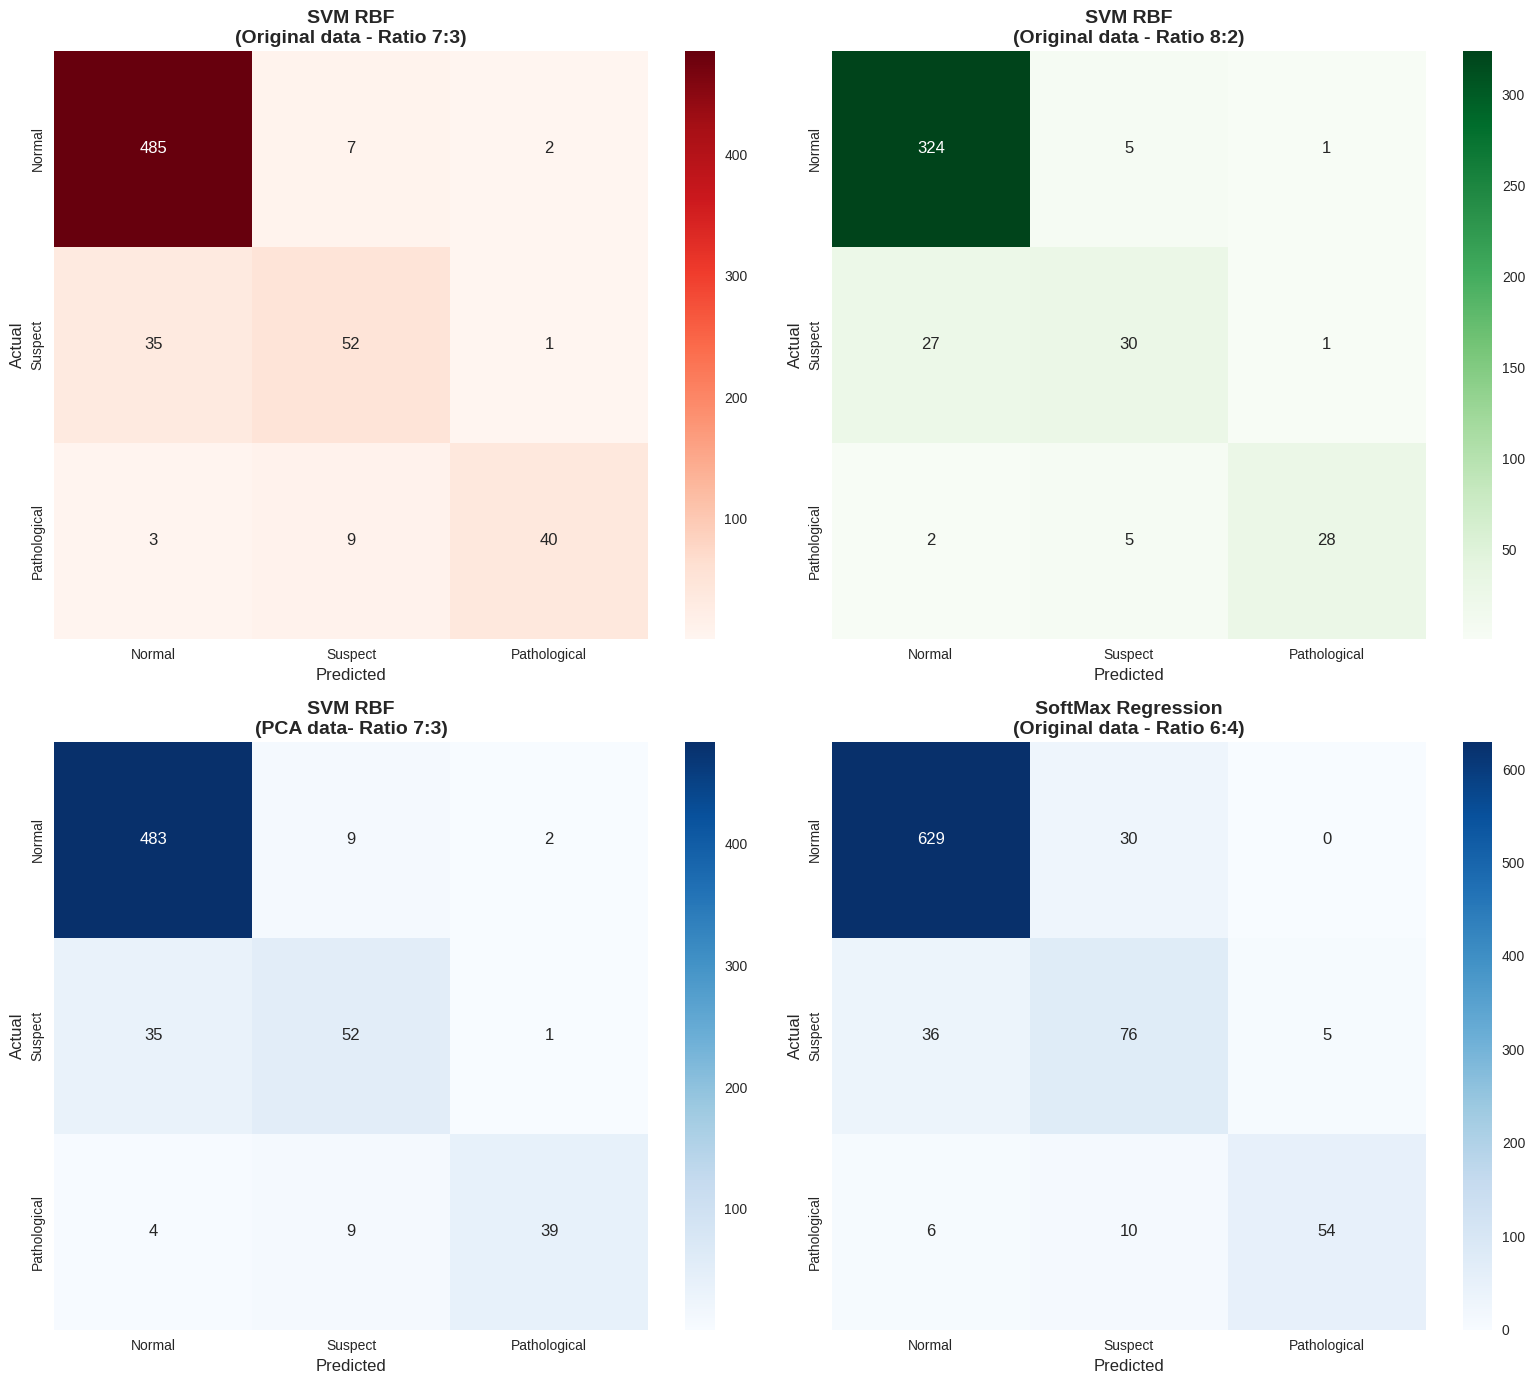

In [34]:
from sklearn.metrics import confusion_matrix

top_models = [
    ("SVM", "7:3", "Gốc", "SVM RBF\n(Original data - Ratio 7:3)"),
    ("SVM", "8:2", "Gốc", "SVM RBF\n(Original data - Ratio 8:2)"),
    ("SVM", "7:3", "PCA", "SVM RBF\n(PCA data- Ratio 7:3)"),
    ("SoftMax Regression", "6:4", "Gốc", "SoftMax Regression\n(Original data - Ratio 6:4)")
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
labels = ['Normal', 'Suspect', 'Pathological']

for i, (name, ratio, data_type, title) in enumerate(top_models):
    ax = axes[i]
    model = models[name]
    X_train_s, X_test_s, y_train, y_test = splits[ratio]
    if data_type == "Gốc":
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
    elif data_type == "PCA":
        pca_temp = PCA(n_components=0.95)
        X_train_pca_temp = pca_temp.fit_transform(X_train_s)
        X_test_pca_temp = pca_temp.transform(X_test_s)
        model.fit(X_train_pca_temp, y_train)
        y_pred = model.predict(X_test_pca_temp)
    cm = confusion_matrix(y_test, y_pred)
    cmap = 'Reds' if i == 0 else 'Greens' if i == 1 else 'Blues'
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.tight_layout()
# plt.savefig('result/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Tổng kết

1. Đánh giá và lựa chọn mô hình đề xuất

Mô hình tối ưu: Thuật toán Support Vector Machine (SVM) sử dụng hạt nhân phi tuyến RBF, kết hợp kỹ thuật điều chỉnh trọng số (Class Weights) trên tập dữ liệu gốc với tỷ lệ phân chia 7:3.

Kết quả thực nghiệm:

Độ chính xác tổng thể (Accuracy) đạt 90.69% - 91.01%.

Độ nhạy (Recall) đối với lớp Bệnh lý đạt 0.94, đáp ứng tốt yêu cầu giảm thiểu tỷ lệ âm tính giả (False Negative) trong chẩn đoán y tế.

Chỉ số F1-score của lớp Bệnh lý đạt 0.91.

2. Hiệu quả của kỹ thuật giảm chiều dữ liệu (PCA & LDA)

Các phương pháp PCA (giữ lại 95% phương sai) và LDA không làm cải thiện hiệu suất của thuật toán SVM và SoftMax Regression, cho thấy không gian đặc trưng gốc đã đảm bảo thông tin phân loại.

Tuy nhiên, kỹ thuật LDA ghi nhận hiệu quả rõ rệt trên thuật toán Naive Bayes, giúp cải thiện độ chính xác từ ~68% lên 86.76% (tại tỷ lệ 6:4) nhờ khả năng tối ưu hóa ranh giới phân lớp và giảm nhiễu đặc trưng.

3. Khả năng tổng quát hóa và kiểm định Overfitting

Độ chênh lệch độ chính xác giữa tập huấn luyện (Train) và tập kiểm thử (Test) của các mô hình thử nghiệm đều được duy trì trong giới hạn kiểm soát (≤ 4%).

Mô hình đề xuất SVM (RBF) ghi nhận độ chênh lệch dao động trong khoảng 2.03% - 3.2%. Kết quả này nằm trong ngưỡng an toàn, minh chứng cho việc mô hình có khả năng tổng quát hóa tốt trên dữ liệu mới và không xảy ra hiện tượng quá khớp (Overfitting).


Quyết định chọn SVM trên Dữ liệu Gốc (Tỉ lệ 7:3) làm mô hình triển khai cuối cùng. Để tối ưu hóa hơn nữa, hướng phát triển tiếp theo sẽ là áp dụng tinh chỉnh trọng số để tăng cường độ nhạy (Recall) cho lớp Bệnh lý.

# Final model


 Model: SVM (Tăng class weight)

[DỮ LIỆU GỐC] Accuracy: 90.69%
              precision    recall  f1-score   support

         1.0       0.98      0.91      0.95       494
         2.0       0.63      0.85      0.72        88
         3.0       0.88      0.94      0.91        52

    accuracy                           0.91       634
   macro avg       0.83      0.90      0.86       634
weighted avg       0.92      0.91      0.91       634



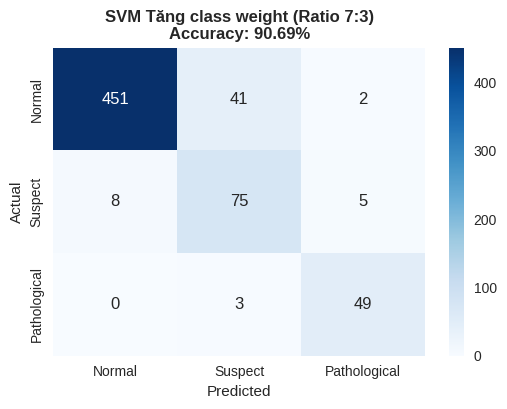

In [35]:
X_train_s, X_test_s, y_train, y_test = splits["7:3"]

# Tăng class weight
custom_weights = {1.0: 1, 2.0: 3, 3.0: 7}
svm_weighted = SVC(kernel='rbf', probability=True, class_weight=custom_weights)

# Train model
svm_weighted.fit(X_train_s, y_train)
y_pred_weighted = svm_weighted.predict(X_test_s)
acc_weighted = accuracy_score(y_test, y_pred_weighted)

print(f"\n Model: SVM (Tăng class weight)")
print(f"\n[DỮ LIỆU GỐC] Accuracy: {acc_weighted:.2%}")

# Report
print(classification_report(y_test, y_pred_weighted, zero_division=0))

# Confusion Matrix
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Suspect', 'Pathological'],
            yticklabels=['Normal', 'Suspect', 'Pathological'])
plt.title(f"SVM Tăng class weight (Ratio 7:3)\nAccuracy: {acc_weighted:.2%}", fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
# plt.savefig('result/figures/confusion_final_svm.png', dpi=300, bbox_inches='tight')
plt.show()

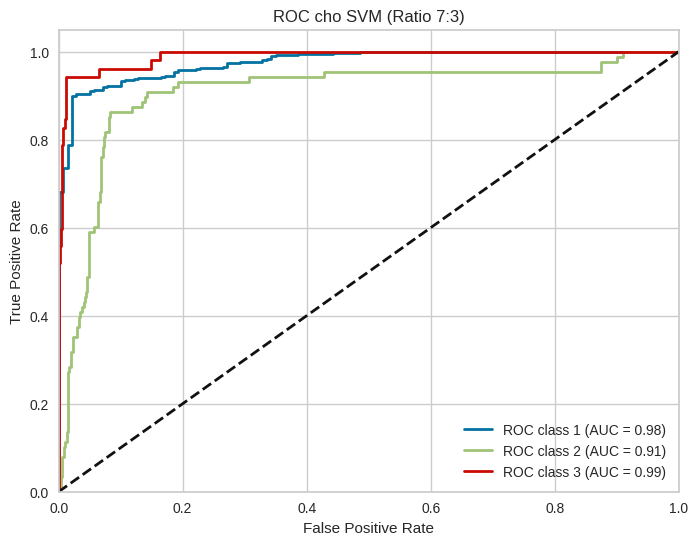

In [36]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[1.0, 2.0, 3.0])
y_score = svm_weighted.decision_function(X_test_s)

fpr, tpr, roc_auc = {}, {}, {}
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'ROC class {i+1} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC cho SVM (Ratio 7:3)')
plt.legend(loc="lower right")
# plt.savefig('result/figures/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

* Việc thiết lập trọng số phạt lớp Bệnh lý lên gấp 7 lần là yếu tố then chốt để giải quyết bài toán mất cân bằng dữ liệu và ưu tiên an toàn trong chẩn đoán.
* Hiệu suất định lượng trên tập kiểm thử (Test Set):
  
    Mô hình cuối cùng đạt được các chỉ số hiệu năng thực nghiệm vượt trội so với các cấu hình cơ bản:

    Độ chính xác tổng thể (Accuracy): 90.69%.

    Khả năng nhận diện lớp Bệnh lý (Lớp 3.0):

    Recall (Độ nhạy): 0.94 (Chỉ lọt lưới 6% các ca thực sự có bệnh).

    F1-Score: 0.91 (Sự cân bằng tối ưu giữa độ chính xác dự báo và khả năng bao phủ).

    Khả năng nhận diện lớp Nghi ngờ (Lớp 2.0): Recall đạt 0.85, cho thấy khả năng phân loại tốt các ca bệnh ở giai đoạn ranh giới.

* Đánh giá tính ổn định và khả năng ứng dụng:

    Kiểm soát Overfitting: Độ chênh lệch giữa độ chính xác tập huấn luyện và tập kiểm thử duy trì ở mức ~2.03%. Con số này chứng minh mô hình có khả      năng tổng quát hóa tốt, không bị tình trạng quá khớp dữ liệu huấn luyện.

  Giá trị lâm sàng: Bằng cách chấp nhận một tỷ lệ nhỏ báo động giả ở lớp Bình thường để đổi lấy độ nhạy 0.94 ở lớp Bệnh lý, mô hình đã đáp ứng đúng     tiêu chuẩn khắt khe của các hệ thống hỗ trợ quyết định y khoa (Clinical Decision Support Systems), nơi ưu tiên tối đa việc không bỏ sót các trường    hợp nguy hiểm đến tính mạng thai nhi.

## Chuyển sang bài toán hồi quy

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
print("CHUYỂN ĐỔI BÀI TOÁN: DỰ ĐOÁN XÁC SUẤT CLASS Pathological (3.0)")

y_train_reg = svm_weighted.predict_proba(X_train_s)[:, 2]
y_test_reg = svm_weighted.predict_proba(X_test_s)[:, 2]

print(f"- Số lượng nhãn train: {len(y_train_reg)}")
print(f"- Số lượng nhãn test: {len(y_test_reg)}")



CHUYỂN ĐỔI BÀI TOÁN: DỰ ĐOÁN XÁC SUẤT CLASS Pathological (3.0)
- Số lượng nhãn train: 1479
- Số lượng nhãn test: 634


In [38]:
# THỰC HIỆN TRÊN DỮ LIỆU GỐC


# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_s)
print(f"Linear Regression -> R2: {r2_score(y_test_reg, y_pred_lin):.4f} | MSE: {mean_squared_error(y_test_reg, y_pred_lin):.4f}")

# KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_s, y_train_reg)
y_pred_knn = knn_reg.predict(X_test_s)
print(f"KNN Regressor     -> R2: {r2_score(y_test_reg, y_pred_knn):.4f} | MSE: {mean_squared_error(y_test_reg, y_pred_knn):.4f}")

Linear Regression -> R2: 0.6467 | MSE: 0.0186
KNN Regressor     -> R2: 0.9205 | MSE: 0.0042


In [39]:
# THỰC HIỆN TRÊN DỮ LIỆU PCA (GIẢM CÒN 1/3 SỐ CHIỀU)

# Tính số chiều mới và áp dụng PCA
n_components = max(1, X_train_s.shape[1] // 3)
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

# Linear Regression trên PCA
lin_reg_pca = LinearRegression()
lin_reg_pca.fit(X_train_pca, y_train_reg)
y_pred_lin_pca = lin_reg_pca.predict(X_test_pca)
print(f"Linear Reg (PCA)  -> R2: {r2_score(y_test_reg, y_pred_lin_pca):.4f} | MSE: {mean_squared_error(y_test_reg, y_pred_lin_pca):.4f}")

# KNN Regressor trên PCA
knn_reg_pca = KNeighborsRegressor(n_neighbors=5)
knn_reg_pca.fit(X_train_pca, y_train_reg)
y_pred_knn_pca = knn_reg_pca.predict(X_test_pca)
print(f"KNN Reg (PCA)     -> R2: {r2_score(y_test_reg, y_pred_knn_pca):.4f} | MSE: {mean_squared_error(y_test_reg, y_pred_knn_pca):.4f}")


Linear Reg (PCA)  -> R2: 0.5301 | MSE: 0.0247
KNN Reg (PCA)     -> R2: 0.9093 | MSE: 0.0048


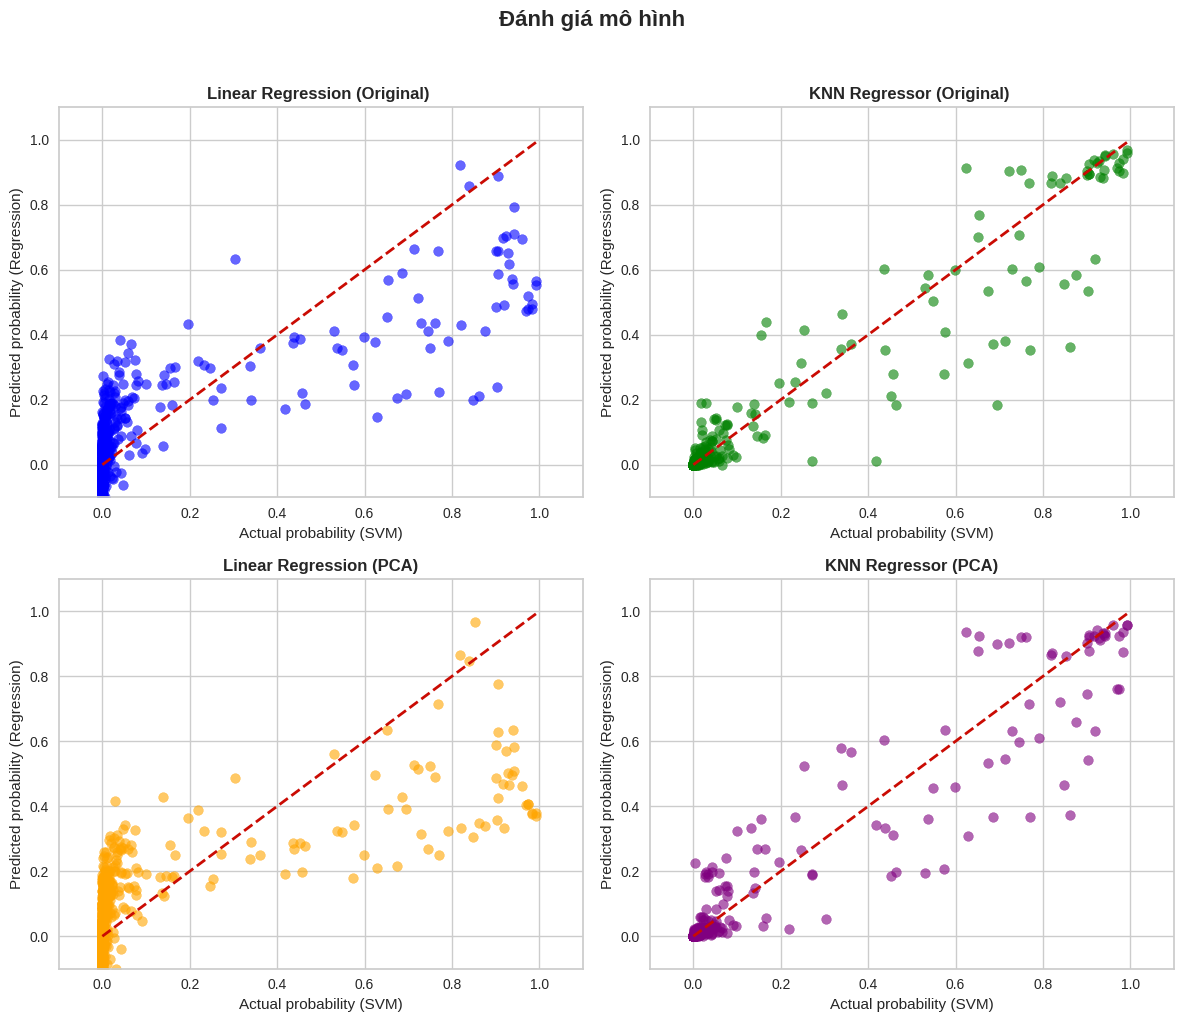

In [40]:
# Thiết lập khung đồ thị 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Hàm vẽ biểu đồ phụ
def plot_regression(ax, y_true, y_pred, title, color):
    ax.scatter(y_true, y_pred, alpha=0.6, color=color)
    # Vẽ đường chéo y=x
    ax.plot([0, 1], [0, 1], 'r--', lw=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Actual probability (SVM)")
    ax.set_ylabel("Predicted probability (Regression)")
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.1, 1.1])

# Gọi hàm vẽ cho 4 trường hợp
plot_regression(axes[0,0], y_test_reg, y_pred_lin, "Linear Regression (Original) ", "blue")
plot_regression(axes[0,1], y_test_reg, y_pred_knn, "KNN Regressor (Original) ", "green")
plot_regression(axes[1,0], y_test_reg, y_pred_lin_pca, "Linear Regression (PCA)", "orange")
plot_regression(axes[1,1], y_test_reg, y_pred_knn_pca, "KNN Regressor (PCA)", "purple")

plt.suptitle("Đánh giá mô hình", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('result/figures/regression_eval.png', dpi=300, bbox_inches='tight')
plt.show()

### ĐÁNH GIÁ VÀ BÀN LUẬN KẾT QUẢ

**1. Tiêu chí đánh giá**
Đánh giá dựa trên biểu đồ phân tán (Scatter Plot) đối chiếu xác suất thực tế từ SVM (trục hoành) và xác suất dự đoán từ mô hình hồi quy (trục tung). Đường tham chiếu $y = x$ đại diện cho trạng thái lý tưởng (sai số bằng 0).

**2. Phân tích trên tập dữ liệu gốc**
* **Linear Regression:** Phân tán rộng, sai lệch lớn. Tại vùng xác suất tiệm cận 0, mô hình nội suy ra giá trị âm (vi phạm giới hạn không gian xác suất $[0, 1]$). Nguyên nhân là do phương trình tuyến tính không đủ độ phức tạp để khớp với ranh giới phi tuyến của SVM (hạt nhân RBF).
* **KNN Regressor:** Dữ liệu hội tụ bám sát đường $y = x$, đặc biệt ở hai vùng cực trị. Với bản chất phi tham số dựa trên khoảng cách lân cận, KNN mô phỏng xuất sắc các ranh giới quyết định phi tuyến.

**3. Phân tích trên tập dữ liệu giảm chiều (PCA - 1/3 số chiều)**
* **Linear Regression (PCA):** Biên độ sai số mở rộng mạnh, mức độ chênh lệch ở khu vực xác suất thấp gia tăng đáng kể.
* **KNN Regressor (PCA):** Độ chính xác nội suy suy giảm nhẹ do mất mát thông tin cấu trúc khi giảm chiều, nhưng vẫn duy trì xu hướng bám sát đường lý tưởng vượt trội so với hồi quy tuyến tính.

**4. Kết luận**
Để mô phỏng hàm quyết định phi tuyến của SVM, **KNN Regressor là lựa chọn tối ưu**, trong khi Linear Regression không phù hợp do vi phạm giả định đầu ra. Đồng thời, kỹ thuật giảm chiều PCA không mang lại hiệu quả cho tác vụ này do gây hao hụt các thông tin phương sai quan trọng của không gian đặc trưng.

In [41]:
# import joblib, pickle, os


# Lưu mô hình
# joblib.dump(svm_weighted, 'results/svm_final_model.pkl')

# Lưu data
# with open('results/data_splits.pkl', 'wb') as f:
#    pickle.dump(splits, f)